# Notebook 01 — Data Loading & Sampling
**CICIoT2023 dataset** | Stratified cap sampling → cleaning → scaling → parquet export

## 1. Setup & Imports

**Sampling strategy.** The raw CICIoT2023 dataset spans 46.7 M rows across 169 CSV files,
requiring 15–20 GB of RAM if loaded in full. We apply a *stratified cap*: the three majority
attack families (DDoS, DoS, Mirai) are capped at 80 000 rows each and Recon at 50 000, while
minority classes (Spoofing, BruteForce, Web-based, Benign) are kept in full. Capping the
majorities reduces memory and training time without discarding any minority-class signal — the
primary challenge in this dataset. This approach is consistent with Al-Ibaisi et al. (2025),
who apply subsampling on this same dataset for the same computational reasons.

In [1]:
import glob, os, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
SEED          = 42
DATA_DIR      = '../data/'
PROCESSED_DIR = '../data/processed/'
GLOB_PATTERN  = os.path.join(DATA_DIR, 'part-*.csv')

CAP = {
    'DDoS':       80_000,
    'DoS':        80_000,
    'Mirai':      80_000,
    'Recon':      50_000,
    'Spoofing':   None,
    'BruteForce': None,
    'Web-based':  None,
    'Benign':     None,
}

LABEL_MAP = {
    'DDoS-ICMP_Flood':'DDoS','DDoS-UDP_Flood':'DDoS','DDoS-TCP_Flood':'DDoS',
    'DDoS-PSHACK_Flood':'DDoS','DDoS-SYN_Flood':'DDoS','DDoS-RSTFINFlood':'DDoS',
    'DDoS-SynonymousIP_Flood':'DDoS','DDoS-ACK_Fragmentation':'DDoS',
    'DDoS-UDP_Fragmentation':'DDoS','DDoS-ICMP_Fragmentation':'DDoS',
    'DDoS-SlowLoris':'DDoS','DDoS-HTTP_Flood':'DDoS',
    'DoS-UDP_Flood':'DoS','DoS-SYN_Flood':'DoS','DoS-TCP_Flood':'DoS','DoS-HTTP_Flood':'DoS',
    'Recon-PingSweep':'Recon','Recon-OSScan':'Recon','Recon-PortScan':'Recon',
    'VulnerabilityScan':'Recon','Recon-HostDiscovery':'Recon',
    'SqlInjection':'Web-based','CommandInjection':'Web-based','Backdoor_Malware':'Web-based',
    'Uploading_Attack':'Web-based','XSS':'Web-based','BrowserHijacking':'Web-based',
    'DictionaryBruteForce':'BruteForce',
    'DNS_Spoofing':'Spoofing','MITM-ArpSpoofing':'Spoofing',
    'Mirai-greIp':'Mirai','Mirai-greEth':'Mirai','Mirai-udpplain':'Mirai',
    'BenignTraffic':'Benign',
}

CONSTANT_COLS  = ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']
DROP_CORR_COLS = ['Srate']

Path(PROCESSED_DIR).mkdir(parents=True, exist_ok=True)

## 2. Data Loading with Stratified Cap Sampling

Files are loaded **in parallel** with `ThreadPoolExecutor` (up to 8 workers) so I/O and CSV
parsing overlap across files. A `tqdm` bar tracks progress. Columns that will be dropped
(constant + correlated) are skipped at read time via `usecols`, reducing both parse time and
peak memory. Per-file quotas cap majority categories uniformly across all 169 files; minority
classes keep all rows. After the parallel phase, frames are concatenated per category and
trimmed to the global cap to correct for integer-division rounding.

In [3]:
files   = sorted(glob.glob(GLOB_PATTERN))
n_files = len(files)
quotas  = {cat: (cap // n_files if cap is not None else None) for cat, cap in CAP.items()}

# Skip dropped columns at read time — saves memory and parse time
_hdr     = pd.read_csv(files[0], nrows=0)
USE_COLS = [c for c in _hdr.columns if c not in set(CONSTANT_COLS + DROP_CORR_COLS)]
del _hdr

def _load_file(f):
    chunk = pd.read_csv(f, usecols=USE_COLS)
    chunk['category'] = chunk['label'].map(LABEL_MAP)
    result = {}
    for cat in CAP:
        rows = chunk[chunk['category'] == cat]
        if quotas[cat] is not None and len(rows) > quotas[cat]:
            rows = rows.sample(n=quotas[cat], random_state=SEED)
        if len(rows) > 0:
            result[cat] = rows
    return result

cat_frames = {cat: [] for cat in CAP}

n_workers = min(os.cpu_count() or 4, 8)
with ThreadPoolExecutor(max_workers=n_workers) as executor:
    futures = {executor.submit(_load_file, f): f for f in files}
    for future in tqdm(as_completed(futures), total=n_files, desc='Loading CSVs', unit='file'):
        for cat, rows in future.result().items():
            cat_frames[cat].append(rows)

# Concatenate and apply global cap (corrects for integer-division rounding)
parts = []
for cat, frames in cat_frames.items():
    if not frames:
        continue
    combined = pd.concat(frames, ignore_index=True)
    if CAP[cat] is not None and len(combined) > CAP[cat]:
        combined = combined.sample(n=CAP[cat], random_state=SEED)
    parts.append(combined)

df = pd.concat(parts, ignore_index=True)
del parts, cat_frames

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f'Shape : {df.shape}')
print(f'Memory: {mem_mb:.1f} MB')
print()
print('Per-category counts:')
print(df['category'].value_counts().to_string())

Loading CSVs:   0%|          | 0/169 [00:00<?, ?file/s]

Shape : (1912258, 41)
Memory: 665.9 MB

Per-category counts:
category
Benign        1098195
Spoofing       486504
DDoS            79937
DoS             79937
Mirai           79937
Recon           49855
Web-based       24829
BruteForce      13064


## 3. Data Cleaning

Four cleaning steps are applied in sequence, with row/column counts reported at each step.

1. **Unmapped labels** — rows whose `label` string has no entry in `LABEL_MAP` produce `NaN`
   in `category`. These were quantified in notebook 00 as ~18 K rows (label variants absent
   from the mapping).
2. **Constant columns** — `ece_flag_number`, `cwr_flag_number`, `Telnet`, `SMTP`, `IRC`, and
   `DHCP` have zero variance across the entire dataset and carry no discriminative signal.
3. **Highly correlated column** — `Srate` is near-perfectly correlated with `Rate`
   (|r| ≈ 0.99, confirmed in notebook 00). Retaining both provides no additional information
   and unnecessarily inflates the feature space.
4. **Duplicate rows** — exact duplicates are redundant for training and can bias learned
   decision boundaries.

In [4]:
n0 = len(df)

# 1. Drop unmapped labels
df = df.dropna(subset=['category'])
print(f'Dropped unmapped labels  : {n0 - len(df):,} rows')

# 2. Drop constant columns
existing_const = [c for c in CONSTANT_COLS if c in df.columns]
df = df.drop(columns=existing_const)
print(f'Dropped constant cols    : {existing_const}')

# 3. Drop highly correlated columns
existing_corr = [c for c in DROP_CORR_COLS if c in df.columns]
df = df.drop(columns=existing_corr)
print(f'Dropped correlated cols  : {existing_corr}')

# 4. Drop duplicate rows
n1 = len(df)
df = df.drop_duplicates()
print(f'Dropped duplicate rows   : {n1 - len(df):,} rows')

feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print()
print(f'Final shape  : {df.shape}')
print(f'Feature count: {len(feature_cols)}')

Dropped unmapped labels  : 0 rows
Dropped constant cols    : []
Dropped correlated cols  : []
Dropped duplicate rows   : 1 rows

Final shape  : (1912257, 41)
Feature count: 39


## 4. Class Distribution After Cleaning

The caps reduce the dominance of DDoS, DoS, and Mirai — which together constituted >90 % of
the raw dataset — to a more balanced upper tier. However, the imbalance ratio relative to the
smallest minority class remains substantial. This is intentional: the caps make the pipeline
computationally feasible without eliminating the imbalance problem. Class imbalance mitigation
(class-weighted loss and/or SMOTE oversampling) is the responsibility of notebook 02.

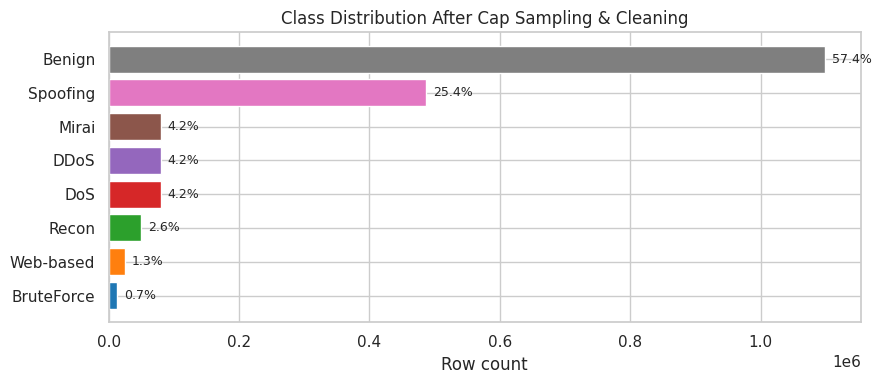

Imbalance ratio (max/min): 84.1x


In [5]:
cat_counts = df['category'].value_counts().sort_values(ascending=True)
cat_pct    = (cat_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('tab10', len(cat_counts))
bars = ax.barh(cat_counts.index, cat_counts.values, color=colors)
for bar, pct in zip(bars, cat_pct.values):
    ax.text(bar.get_width() + cat_counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Row count')
ax.set_title('Class Distribution After Cap Sampling & Cleaning')
plt.tight_layout()
plt.show()

imbalance = cat_counts.max() / cat_counts.min()
print(f'Imbalance ratio (max/min): {imbalance:.1f}x')

## 5. Feature Matrix & Label Encoding

`LabelEncoder` assigns a stable integer index to each category string in alphabetical order.
The mapping is printed here for reference — it must be stored alongside the trained model so
that predicted integers can be decoded back to attack category names in notebook 03. The
feature matrix `X` contains only the 39 numeric columns; the string columns `label` and
`category` are excluded.

In [6]:
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X     = df[feature_cols].values
y_raw = df['category'].values

le = LabelEncoder()
y  = le.fit_transform(y_raw)

print('Class → index mapping:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx}  {cls}')

print()
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}  |  unique classes: {len(le.classes_)}')

Class → index mapping:
  0  Benign
  1  BruteForce
  2  DDoS
  3  DoS
  4  Mirai
  5  Recon
  6  Spoofing
  7  Web-based

X shape: (1912257, 39)
y shape: (1912257,)  |  unique classes: 8


## 6. Stratified Train / Validation / Test Split

The dataset is split **70 % train / 15 % validation / 15 % test** via two consecutive
stratified `train_test_split` calls. Stratification on `y` ensures each split mirrors the
full dataset's class proportions. Without stratification, a random split risks assigning zero
(or near-zero) samples of minority classes such as BruteForce or Web-based to the validation
and test sets, rendering per-class evaluation metrics meaningless. Class proportions are
verified numerically after the split.

In [7]:
# 70 / 30 first pass
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

# Split the 30 % temp evenly → 15 % val + 15 % test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Train : {X_train.shape}   ({len(X_train) / len(X) * 100:.1f} %)')
print(f'Val   : {X_val.shape}   ({len(X_val)   / len(X) * 100:.1f} %)')
print(f'Test  : {X_test.shape}   ({len(X_test)  / len(X) * 100:.1f} %)')

# Verify class proportions are preserved across splits
idx_to_cls = dict(enumerate(le.classes_))
prop_df = pd.DataFrame({
    name: (pd.Series(y_split)
              .map(idx_to_cls)
              .value_counts(normalize=True)
              .round(3))
    for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]
}).sort_index()

print()
print('Class proportions per split:')
print(prop_df.to_string())

Train : (1338579, 39)   (70.0 %)
Val   : (286839, 39)   (15.0 %)
Test  : (286839, 39)   (15.0 %)

Class proportions per split:
            Train    Val   Test
Benign      0.574  0.574  0.574
BruteForce  0.007  0.007  0.007
DDoS        0.042  0.042  0.042
DoS         0.042  0.042  0.042
Mirai       0.042  0.042  0.042
Recon       0.026  0.026  0.026
Spoofing    0.254  0.254  0.254
Web-based   0.013  0.013  0.013


## 7. Scaling with RobustScaler

`RobustScaler` is **fit on the training set only**. Fitting on validation or test data would
constitute *data leakage*: the scaler would encode information about the test distribution,
invalidating the independence of the held-out evaluation. `RobustScaler` was chosen over
`StandardScaler` because it is parameterised by the median and IQR rather than mean and
standard deviation, making it insensitive to the extreme outliers confirmed in notebook 00
(`Rate`, `IAT`, `Header_Length` all showed boxplot whiskers at orders-of-magnitude from the
median). After scaling, three key features are verified: the training median should be ≈ 0
and the IQR ≈ 1.

In [8]:
scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Verify transformation on 3 key features
check     = ['Header_Length', 'Rate', 'IAT']
check_idx = [feature_cols.index(c) for c in check]

header = f'{"Feature":<20}  {"Before med":>12}  {"Before IQR":>12}  {"After med":>12}  {"After IQR":>12}'
print(header)
print('-' * len(header))
for feat, idx in zip(check, check_idx):
    bmed = np.median(X_train[:, idx])
    biqr = np.percentile(X_train[:, idx], 75) - np.percentile(X_train[:, idx], 25)
    amed = np.median(X_train_scaled[:, idx])
    aiqr = np.percentile(X_train_scaled[:, idx], 75) - np.percentile(X_train_scaled[:, idx], 25)
    print(f'{feat:<20}  {bmed:>12.4f}  {biqr:>12.4f}  {amed:>12.4f}  {aiqr:>12.4f}')

Feature                 Before med    Before IQR     After med     After IQR
----------------------------------------------------------------------------
Header_Length          379191.0000  1372769.6500        0.0000        1.0000
Rate                       58.0059      114.3744        0.0000        1.0000
IAT                   83149334.0704  166522439.0285        0.0000        1.0000


## 8. Export to Parquet

Each split is saved as a single Parquet file containing the scaled feature columns plus an
integer label column `y`. Parquet is preferred over CSV for three reasons: (1) columnar
compression yields files ~5× smaller on disk; (2) float64 precision is preserved exactly,
avoiding the rounding inherent in text serialisation; (3) `pd.read_parquet` is substantially
faster than `pd.read_csv` when loading in notebooks 02 and 03.

In [9]:
def save_split(X_scaled, y_arr, filename):
    out  = pd.DataFrame(X_scaled, columns=feature_cols)
    out['y'] = y_arr
    path = os.path.join(PROCESSED_DIR, filename)
    out.to_parquet(path, index=False)
    size_mb = os.path.getsize(path) / 1e6
    print(f'  {filename:<20}  {str(out.shape):<22}  {size_mb:.1f} MB')

print(f'  {"File":<20}  {"Shape":<22}  Size')
print('  ' + '-' * 52)
save_split(X_train_scaled, y_train, 'train.parquet')
save_split(X_val_scaled,   y_val,   'val.parquet')
save_split(X_test_scaled,  y_test,  'test.parquet')

  File                  Shape                   Size
  ----------------------------------------------------
  train.parquet         (1338579, 40)           125.6 MB
  val.parquet           (286839, 40)            28.0 MB
  test.parquet          (286839, 40)            28.0 MB
